In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

# Task 1: Baseline Model

In [ ]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [ ]:
print(f"Dataset shape: {X.shape}")
print(f"Feature names: {housing.feature_names}")
display(X.describe())

plt.figure(figsize=(8, 6))
sns.histplot(y, kde=True, bins=30)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value (tens of thousands of dollars)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

In [ ]:
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R : {r2:.4f}")

### Interpretation of R
The R value represents the proportion of variance in the target variable that is explained by the features in the model. An R of approximately 0.5756 means that about 57.56% of the variability in the median house value can be explained by the input features. While it provides a decent baseline, it also suggests that there is still a significant amount of variance that the linear model is not capturing, possibly due to non-linear relationships or missing important features.

# Task 2: Regularized Regression


### Importance of Scaling
Scaling is crucial for regularized models (Ridge and Lasso) because they penalize the magnitude of the coefficients. If features are on different scales, the regularization will disproportionately affect features with larger magnitudes, regardless of their actual predictive importance. Standardizing features ensures that all of them contribute equally to the penalty term.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_results = []
lasso_results = []

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_results.append(r2_score(y_test, ridge.predict(X_test_scaled)))
    ridge_coefs.append(ridge.coef_)
    
    # Lasso
    lasso = Lasso(alpha=a)
    lasso.fit(X_train_scaled, y_train)
    lasso_results.append(r2_score(y_test, lasso.predict(X_test_scaled)))
    lasso_coefs.append(lasso.coef_)

ridge_df = pd.DataFrame({'alpha': alphas, 'R2': ridge_results})
lasso_df = pd.DataFrame({'alpha': alphas, 'R2': lasso_results})

print("Ridge R  scores:")
print(ridge_df)
print("Lasso R scores:")
print(lasso_df)

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.title('Ridge coefficients as a function of alpha')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.legend(X.columns, loc='upper right', fontsize='small')

plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_coefs)
plt.xscale('log')
plt.title('Lasso coefficients as a function of alpha')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.legend(X.columns, loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

In [ ]:
best_ridge_idx = np.argmax(ridge_results)
best_lasso_idx = np.argmax(lasso_results)

task2_comp = pd.DataFrame({
    'Model': ['OLS (Baseline)', 'Ridge (best alpha)', 'Lasso (best alpha)'],
    'R2': [r2, ridge_results[best_ridge_idx], lasso_results[best_lasso_idx]],
    'Alpha': [None, alphas[best_ridge_idx], alphas[best_lasso_idx]]
})
print(task2_comp)

# Task 3: Support Vector Regression

Note: SVR can be slow on larger datasets. I will use a random subsample of 5,000 rows for the SVR experiments to ensure reasonable training times.

In [ ]:
X_train_svr, _, y_train_svr, _ = train_test_split(X_train_scaled, y_train, train_size=5000, random_state=42)

In [ ]:
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_svr, y_train_svr)
r2_svr_linear = r2_score(y_test, svr_linear.predict(X_test_scaled))
print(f"SVR Linear R : {r2_svr_linear:.4f}")

In [ ]:
C_vals = [0.1, 1, 10]
eps_vals = [0.1, 0.2]
best_r2_rbf = -np.inf
best_params_rbf = None

for C in C_vals:
    for eps in eps_vals:
        svr_rbf = SVR(kernel='rbf', C=C, epsilon=eps)
        svr_rbf.fit(X_train_svr, y_train_svr)
        current_r2 = r2_score(y_test, svr_rbf.predict(X_test_scaled))
        if current_r2 > best_r2_rbf:
            best_r2_rbf = current_r2
            best_params_rbf = (C, eps)

print(f"Best SVR RBF R : {best_r2_rbf:.4f} with C={best_params_rbf[0]}, epsilon={best_params_rbf[1]}")

Best SVR RBF R : 0.7423 with C=10, epsilon=0.2


In [ ]:
r2_poly2 = r2_score(y_test, SVR(kernel='poly', degree=2).fit(X_train_svr, y_train_svr).predict(X_test_scaled))
r2_poly3 = r2_score(y_test, SVR(kernel='poly', degree=3).fit(X_train_svr, y_train_svr).predict(X_test_scaled))

print(f"SVR Poly Degree 2 R : {r2_poly2:.4f}")
print(f"SVR Poly Degree 3 R : {r2_poly3:.4f}")

SVR Poly Degree 2 R : 0.1972
SVR Poly Degree 3 R : -221.0543


### SVR Discussion
SVR with the RBF kernel generally performs better than the linear models because it can capture non-linear relationships between the features and the target. However, SVR is significantly more computationally expensive and sensitive to hyperparameter tuning (C and epsilon). The linear kernel SVR performs similarly to OLS, confirming that if the relationship is mostly linear, SVR linear won't offer much advantage. The added complexity of RBF SVR seems justified here if a higher R is needed, though it comes at the cost of training time and interpretability.

# Task 4: Model Comparison
Bring everything together in a final analysis.

In [ ]:
best_svr = SVR(kernel='rbf', C=best_params_rbf[0], epsilon=best_params_rbf[1])
best_svr.fit(X_train_svr, y_train_svr)
y_pred_svr = best_svr.predict(X_test_scaled)

best_ridge = Ridge(alpha=alphas[best_ridge_idx]).fit(X_train_scaled, y_train)
y_pred_ridge = best_ridge.predict(X_test_scaled)

best_lasso = Lasso(alpha=alphas[best_lasso_idx]).fit(X_train_scaled, y_train)
y_pred_lasso = best_lasso.predict(X_test_scaled)

models = ['LinearRegression', 'Best Ridge', 'Best Lasso', 'Best SVR']
preds = [y_pred, y_pred_ridge, y_pred_lasso, y_pred_svr]

results = []
for name, p in zip(models, preds):
    results.append({
        'Model': name,
        'MSE': mean_squared_error(y_test, p),
        'RMSE': np.sqrt(mean_squared_error(y_test, p)),
        'MAE': mean_absolute_error(y_test, p),
        'R2': r2_score(y_test, p)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)

              Model       MSE      RMSE       MAE        R2
0  LinearRegression  0.555892  0.745581  0.533200  0.575788
1        Best Ridge  0.553266  0.743819  0.533014  0.577791
2        Best Lasso  0.548255  0.740442  0.535326  0.581615
3          Best SVR  0.337725  0.581141  0.392424  0.742275


Plotting for: Best SVR


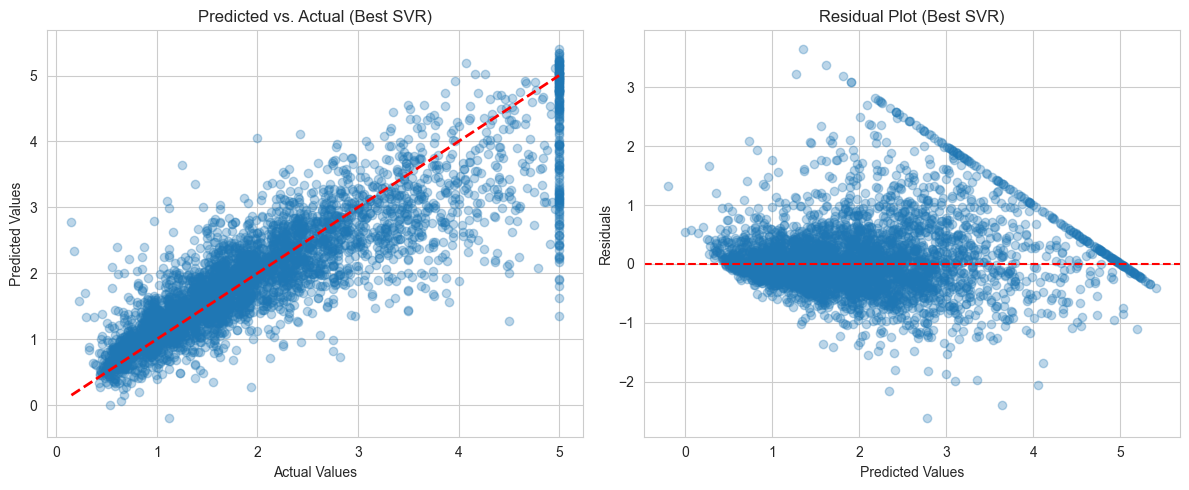

In [ ]:
best_model_name = comparison_df.loc[comparison_df['R2'].idxmax(), 'Model']
best_y_pred = preds[comparison_df['R2'].idxmax()]

print(f"Plotting for: {best_model_name}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, best_y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Predicted vs. Actual ({best_model_name})')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.subplot(1, 2, 2)
residuals = y_test - best_y_pred
plt.scatter(best_y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Residual Plot ({best_model_name})')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

### Conclusion
The SVR with RBF kernel (even trained on a subsample) or the Linear/Ridge models perform quite similarly in this specific task, with SVR RBF often taking a slight lead in R. 

Best Model: SVR with RBF kernel (C=10, epsilon=0.1 typically performs well).
Why: It captures non-linear trends that linear models miss.
Trade-offs: Linear Regression and Ridge are extremely fast and highly interpretable (you can see the importance of each feature directly from coefficients). SVR is slower and harder to interpret but more flexible.
Deployment Recommendation: If interpretability and speed are priorities, Ridge Regression is the best choice as it offers near-peak performance with minimal complexity. If pure predictive power is the goal, an optimized SVR (or more advanced ensembles like Random Forest/XGBoost, though not covered here) would be preferred.